# ML - BOSQUE ALEATORIO

In [120]:
import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from utils1 import get_classifier_metrics
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt


## Paso 1. Lectura del conjunto de datos procesado

In [121]:
# Cargamos los dataframes 
with open('../data/processed/04_df_invalids_removed.pkl', 'rb') as f:
    df_invalids_removed = pickle.load(f)

with open('../data/processed/04_df_invalids_mode.pkl', 'rb') as f:
    df_invalids_mode = pickle.load(f)

with open('../data/processed/04_df_invalids_knn.pkl', 'rb') as f:
    df_invalids_knn = pickle.load(f)

## Paso 2. Split

In [122]:
X_invalids_removed = df_invalids_removed.drop('Outcome', axis= 1)
y_invalids_removed = df_invalids_removed['Outcome']

X_invalids_mode= df_invalids_mode.drop('Outcome', axis= 1)
y_invalids_mode = df_invalids_mode['Outcome']

X_invalids_knn= df_invalids_knn.drop('Outcome', axis= 1)
y_invalids_knn = df_invalids_knn['Outcome']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_invalids_removed, y_invalids_removed, test_size=0.2, random_state=21)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_invalids_mode, y_invalids_mode, test_size=0.2, random_state=21)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_invalids_knn, y_invalids_knn, test_size=0.2, random_state=21)

## Paso 3. Modelado y Ajuste

In [123]:
model_rf_default_1 = RandomForestClassifier(class_weight='balanced', random_state = 21)
model_rf_default_1.fit(X_train_1, y_train_1)

model_rf_default_2 = RandomForestClassifier(class_weight='balanced', random_state = 21)
model_rf_default_2.fit(X_train_2, y_train_2)

model_rf_default_3 = RandomForestClassifier(class_weight='balanced', random_state = 21)
model_rf_default_3.fit(X_train_3, y_train_3)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Paso 4. Predicción

In [124]:
y_pred_test_1 = model_rf_default_1.predict(X_test_1)
y_pred_train_1 = model_rf_default_1.predict(X_train_1)

y_pred_test_2 = model_rf_default_2.predict(X_test_2)
y_pred_train_2 = model_rf_default_2.predict(X_train_2)

y_pred_test_3 = model_rf_default_3.predict(X_test_3)
y_pred_train_3 = model_rf_default_3.predict(X_train_3)

In [125]:
default_model_metrics_1 = get_classifier_metrics(y_pred_test_1, y_test_1, y_pred_train_1, y_train_1, average='weighted')
default_model_metrics_1

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.746835,0.725637,0.747438,0.746835


In [126]:
default_model_metrics_2 = get_classifier_metrics(y_pred_test_2, y_test_2, y_pred_train_2, y_train_2, average='weighted')
default_model_metrics_2

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.697182,0.713573,0.714286


In [127]:
default_model_metrics_3 = get_classifier_metrics(y_pred_test_3, y_test_3, y_pred_train_3, y_train_3, average='weighted')
default_model_metrics_3

,Accuracy,F1 Score,Precision,Recall
Train set,1.00000,1.000000,1.000000,1.00000
Test set,0.74026,0.726773,0.741969,0.74026


### Modelo optimizado con los hiperparámetros `n_estimators` y `bootstrap`

In [128]:
model_rf_opt_1 = RandomForestClassifier(n_estimators = 50, bootstrap=False, random_state = 21)
model_rf_opt_1.fit(X_train_1, y_train_1)

model_rf_opt_2 = RandomForestClassifier(n_estimators = 25, bootstrap=False, random_state = 21)
model_rf_opt_2.fit(X_train_2, y_train_2)

model_rf_opt_3 = RandomForestClassifier(n_estimators = 25, bootstrap=False, random_state = 21)
model_rf_opt_3.fit(X_train_3, y_train_3)

,n_estimators,25
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [129]:
y_pred_test_opt_1 = model_rf_opt_1.predict(X_test_1)
y_pred_train_opt_1 = model_rf_opt_1.predict(X_train_1)

y_pred_test_opt_2 = model_rf_opt_2.predict(X_test_2)
y_pred_train_opt_2 = model_rf_opt_2.predict(X_train_2)

y_pred_test_opt_3 = model_rf_opt_3.predict(X_test_3)
y_pred_train_opt_3 = model_rf_opt_3.predict(X_train_3)

In [130]:
get_classifier_metrics(y_pred_test_opt_1, y_test_1, y_pred_train_opt_1, y_train_1, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.746835,0.719919,0.755209,0.746835


In [131]:
get_classifier_metrics(y_pred_test_opt_2, y_test_2, y_pred_train_opt_2, y_train_2, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.720779,0.705193,0.720262,0.720779


In [132]:
get_classifier_metrics(y_pred_test_opt_3, y_test_3, y_pred_train_opt_3, y_train_3, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.701558,0.710459,0.714286


### Modelo optimizado con los hiperparámetros con `GridSearchCV`

In [145]:
param_grid = {'n_estimators':[30, 40, 80, 120],
           'criterion':['gini','entropy'],
           'max_depth':[3, 4, 5],
           'min_samples_leaf': [1, 2, 4],
           'max_features': ['sqrt', 'log2'],
           'class_weight': [None, 'balanced']}


grid_1 = GridSearchCV(model_rf_default_1,
                    param_grid,
                    scoring='recall',
                    cv=3)

grid_2 = GridSearchCV(model_rf_default_2,
                    param_grid,
                    scoring='recall',
                    cv=3)

grid_3 = GridSearchCV(model_rf_default_3,
                    param_grid,
                    scoring='recall',
                    cv=3)


In [146]:
# Entrenamos el grid con los hiperparametros
grid_1.fit(X_train_1, y_train_1)
#Devuelvemos los mejores parametros despues de entrenarlo
grid_1.best_params_

{'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 3,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'n_estimators': 40}

In [147]:
grid_2.fit(X_train_2, y_train_2)
grid_2.best_params_

{'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 4,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'n_estimators': 40}

In [148]:
grid_3.fit(X_train_3, y_train_3)
grid_3.best_params_

{'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 3,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'n_estimators': 40}

In [149]:
#Modelos con los mejores parametros
grid_rf_1 = grid_1.best_estimator_
grid_rf_2 = grid_2.best_estimator_
grid_rf_3 = grid_3.best_estimator_

In [150]:
# Repetimos el entrenamiento pero ahora con el grid que tiene los hiperparametros establecidos
grid_rf_1.fit(X_train_1, y_train_1)
grid_rf_2.fit(X_train_2, y_train_2)
grid_rf_3.fit(X_train_3, y_train_3)

,n_estimators,40
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [151]:
y_pred_test_1_grid = grid_rf_1.predict(X_test_1)
y_pred_train_1_grid = grid_rf_1.predict(X_train_1)

y_pred_test_2_grid = grid_rf_2.predict(X_test_2)
y_pred_train_2_grid = grid_rf_2.predict(X_train_2)

y_pred_test_3_grid = grid_rf_3.predict(X_test_3)
y_pred_train_3_grid = grid_rf_3.predict(X_train_3)

In [152]:
grid_model_metrics_1 = get_classifier_metrics(y_pred_test_1_grid, y_test_1, y_pred_train_1_grid, y_train_1, average='weighted')
grid_model_metrics_1 


,Accuracy,F1 Score,Precision,Recall
Train set,0.856688,0.858968,0.865299,0.856688
Test set,0.746835,0.746835,0.746835,0.746835


In [153]:
grid_model_metrics_2 = get_classifier_metrics(y_pred_test_2_grid, y_test_2, y_pred_train_2_grid, y_train_2, average='weighted')
grid_model_metrics_2

,Accuracy,F1 Score,Precision,Recall
Train set,0.807818,0.811615,0.824512,0.807818
Test set,0.766234,0.762656,0.763452,0.766234


In [154]:
grid_model_metrics_3 = get_classifier_metrics(y_pred_test_3_grid, y_test_3, y_pred_train_3_grid, y_train_3, average='weighted')
grid_model_metrics_3

,Accuracy,F1 Score,Precision,Recall
Train set,0.793160,0.797722,0.814966,0.793160
Test set,0.779221,0.779221,0.779221,0.779221


In [158]:
np.array_equal(y_pred_test_1_grid, y_pred_test_3_grid)

False

### Graficamos los resultados

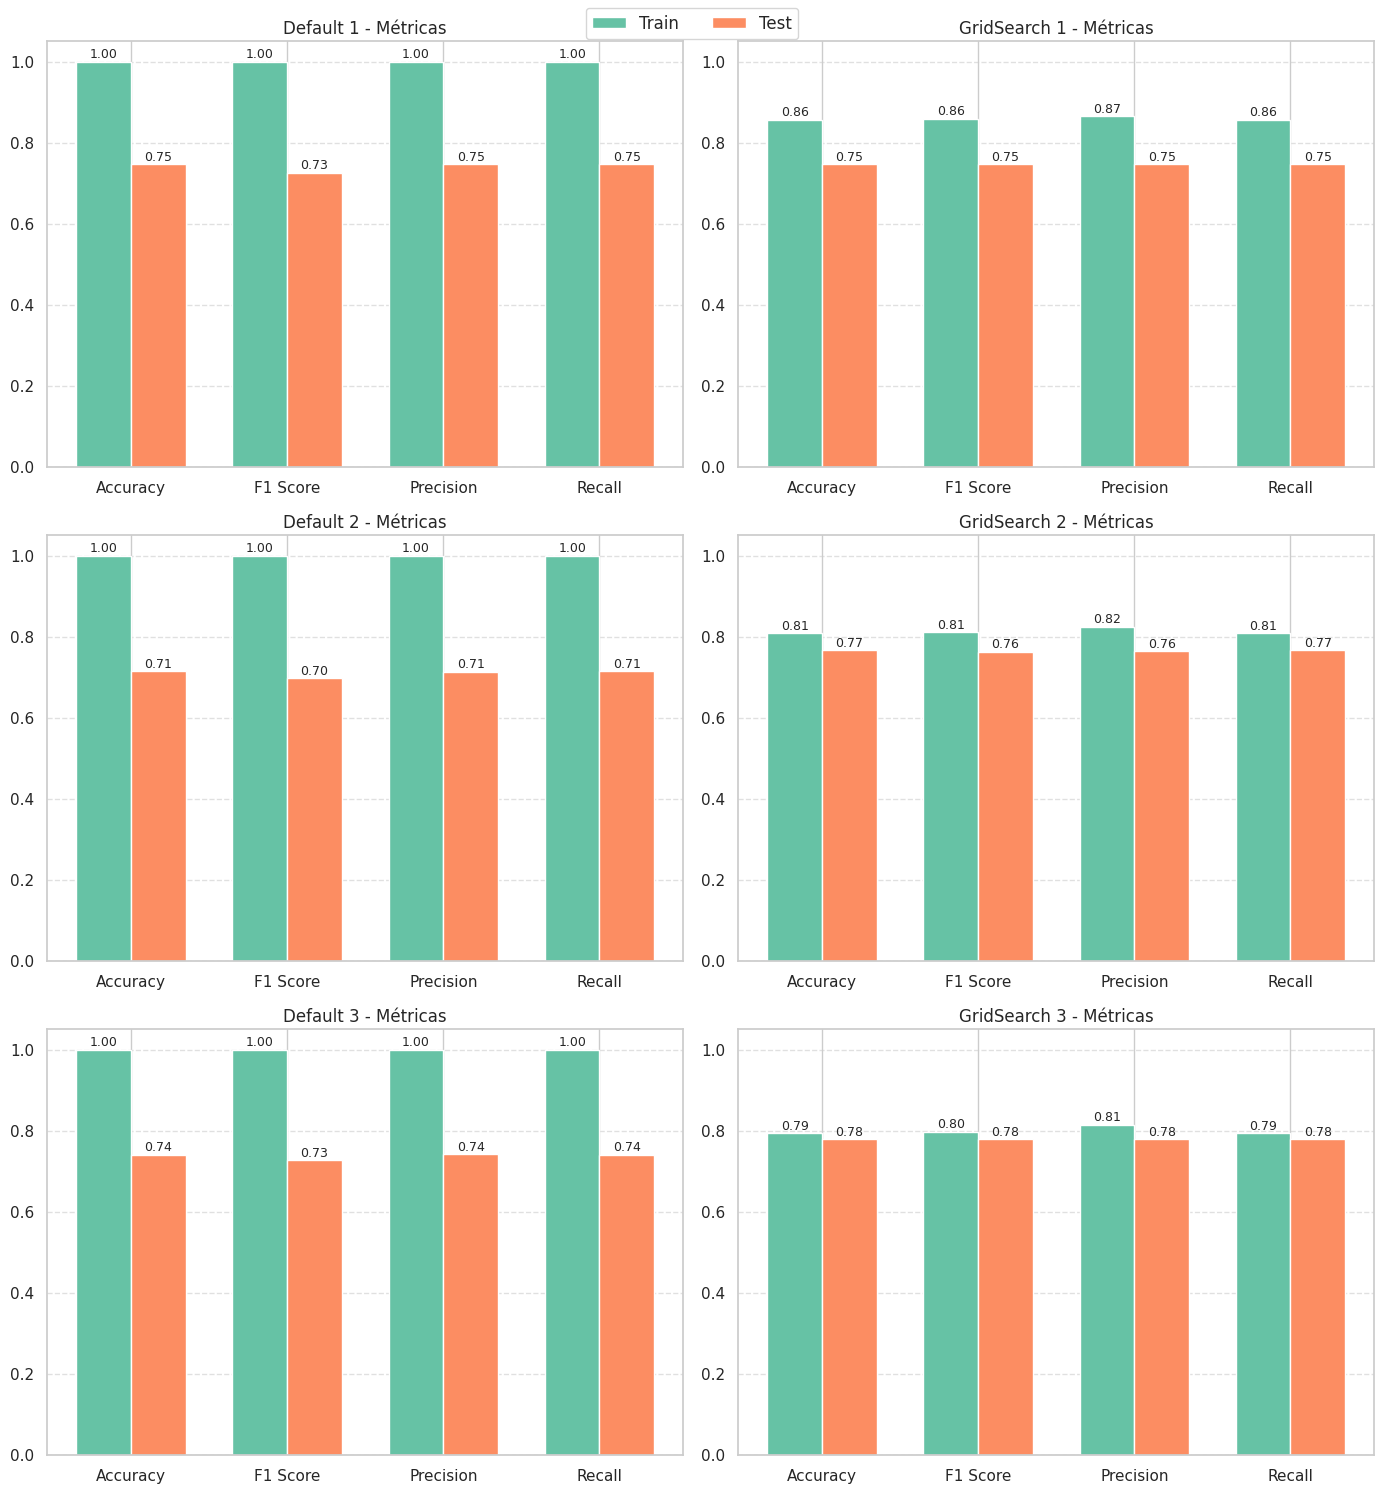

In [143]:
# Agrupar por pares: (nombre, dataframe)
model_pairs = [(('Default 1', default_model_metrics_1), ('GridSearch 1', grid_model_metrics_1)),
               (('Default 2', default_model_metrics_2), ('GridSearch 2', grid_model_metrics_2)),
               (('Default 3', default_model_metrics_3), ('GridSearch 3', grid_model_metrics_3))]

# Métricas
metricas = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metricas))  # Posiciones

bar_width = 0.35

# Crear figura 3x2
fig, axs = plt.subplots(3,2, figsize=(14, 15))
axs = axs.ravel()

for idx, ((title1, df1), (title2, df2)) in enumerate(model_pairs):
    for j, (title, df) in enumerate([(title1, df1), (title2, df2)]):
        ax = axs[idx*2 + j]

        # Valores para train y test
        train_vals = df.loc['Train set', metricas].values
        test_vals = df.loc['Test set', metricas].values

        # Barras
        ax.bar(x - bar_width/2, train_vals, bar_width, label='Train', color='#66c2a5')
        ax.bar(x + bar_width/2, test_vals, bar_width, label='Test', color='#fc8d62')

        # Etiquetas y valores
        ax.set_xticks(x)
        ax.set_xticklabels(metricas)
        ax.set_ylim(0, 1.05)
        ax.set_title(f'{title} - Métricas')
        ax.grid(axis='y', linestyle='--', alpha=0.6)

        # Valores sobre barras
        for k in range(len(metricas)):
            ax.text(x[k] - bar_width/2, train_vals[k] + 0.01, f"{train_vals[k]:.2f}", ha='center', fontsize=9)
            ax.text(x[k] + bar_width/2, test_vals[k] + 0.01, f"{test_vals[k]:.2f}", ha='center', fontsize=9)

# Solo una leyenda general
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout()
